# Required Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset

In [5]:
df = pd.read_csv('retail sales dataset.csv')

# Display First Five Rows

In [6]:
df.head(10)

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,24-11-2023,CUST001,Male,34,Beauty,3,50,150
1,2,27-02-2023,CUST002,Female,26,Clothing,2,500,1000
2,3,13-01-2023,CUST003,Male,50,Electronics,1,30,30
3,4,21-05-2023,CUST004,Male,37,Clothing,1,500,500
4,5,06-05-2023,CUST005,Male,30,Beauty,2,50,100
5,6,25-04-2023,CUST006,Female,45,Beauty,1,30,30
6,7,13-03-2023,CUST007,Male,46,Clothing,2,25,50
7,8,22-02-2023,CUST008,Male,30,Electronics,4,25,100
8,9,13-12-2023,CUST009,Male,63,Electronics,2,300,600
9,10,07-10-2023,CUST010,Female,52,Clothing,4,50,200


In [7]:
df.tail(10)

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
990,991,26-12-2023,CUST991,Female,34,Clothing,2,50,100
991,992,21-08-2023,CUST992,Female,57,Electronics,2,30,60
992,993,06-02-2023,CUST993,Female,48,Electronics,3,50,150
993,994,18-12-2023,CUST994,Female,51,Beauty,2,500,1000
994,995,30-04-2023,CUST995,Female,41,Clothing,1,30,30
995,996,16-05-2023,CUST996,Male,62,Clothing,1,50,50
996,997,17-11-2023,CUST997,Male,52,Beauty,3,30,90
997,998,29-10-2023,CUST998,Female,23,Beauty,4,25,100
998,999,05-12-2023,CUST999,Female,36,Electronics,3,50,150
999,1000,12-04-2023,CUST1000,Male,47,Electronics,4,30,120


# View Dataset

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


In [9]:
df.shape

(1000, 9)

# checking the data there is any null value or not

In [ ]:
df.isnull().sum()

As can you see there was no non values good to go


# As can you see there is no null values

# Visualize Dataset

In [11]:
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [12]:
# unique values od dataset
df.nunique()

Transaction ID      1000
Date                 345
Customer ID         1000
Gender                 2
Age                   47
Product Category       3
Quantity               4
Price per Unit         5
Total Amount          18
dtype: int64

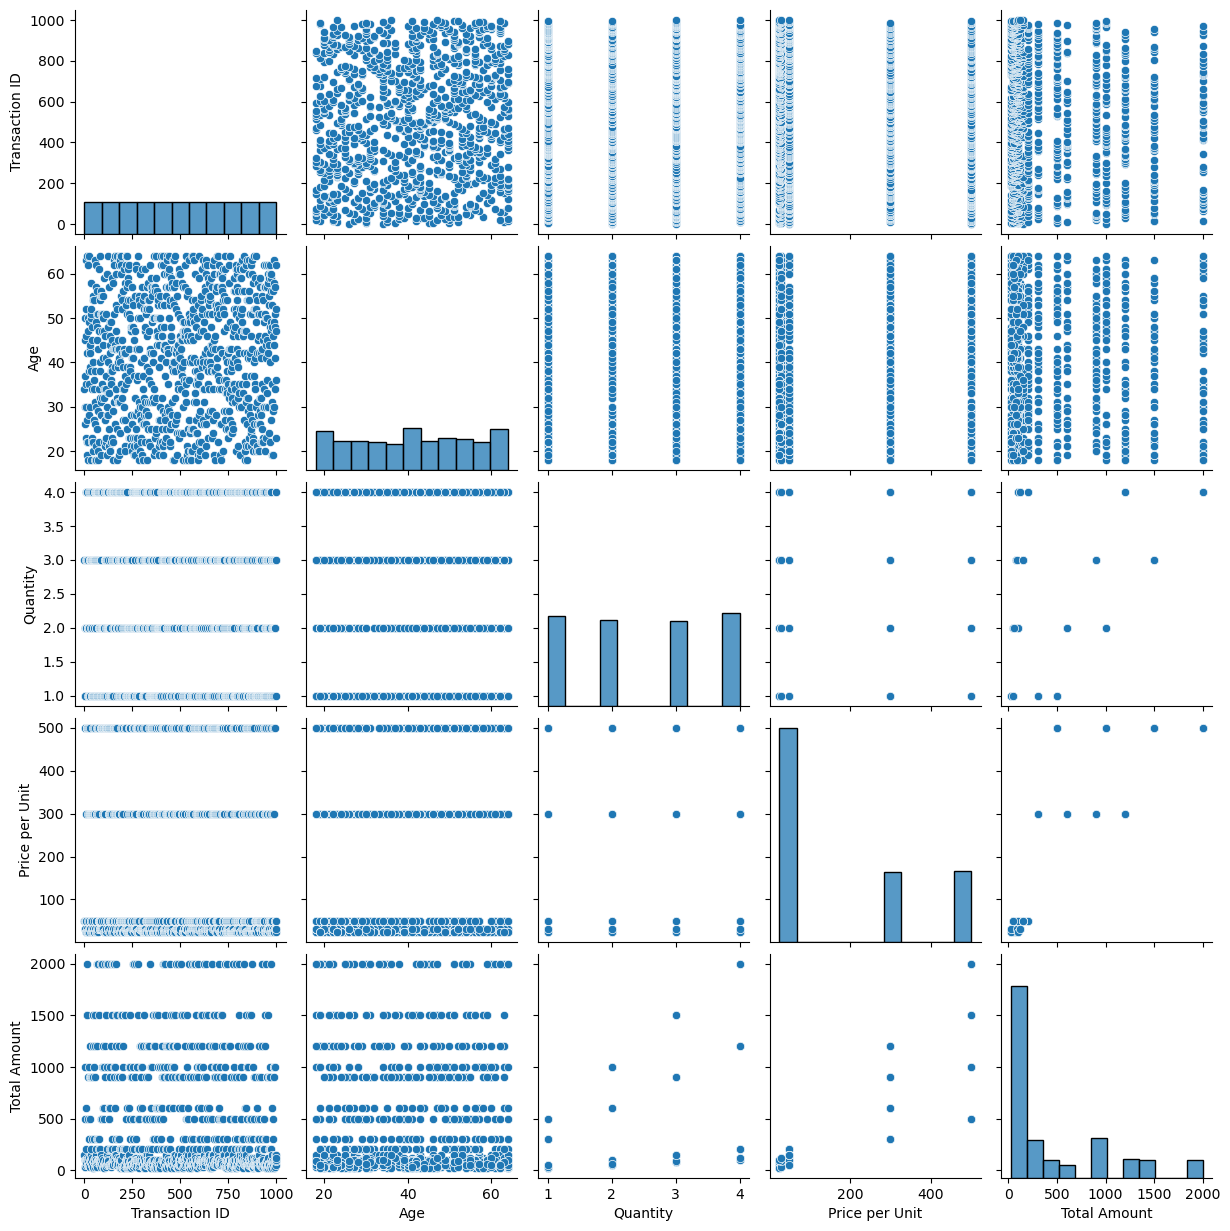

In [13]:
sns.pairplot(df)

# Counting the products in product category

In [14]:
df[df['Product Category'].isin(['clothing','Beauty','electronics'])]['Product Category'].value_counts()

Product Category
Beauty    307
Name: count, dtype: int64

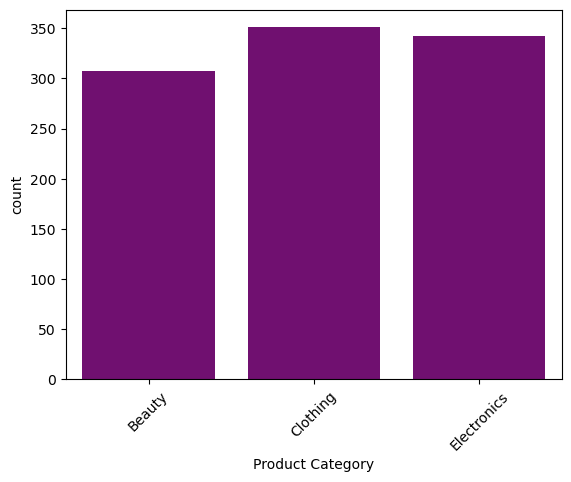

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(x=df['Product Category'], color='purple')

plt.xticks(rotation=45)
plt.show()

# Group your data by product category and summarize it by quantity and total amount

In [16]:
df.groupby('Product Category')[['Quantity','Total Amount']].sum()

,Quantity,Total Amount
Product Category,,
Beauty,771,143515
Clothing,894,155580
Electronics,849,156905


# Comparison using bar graph

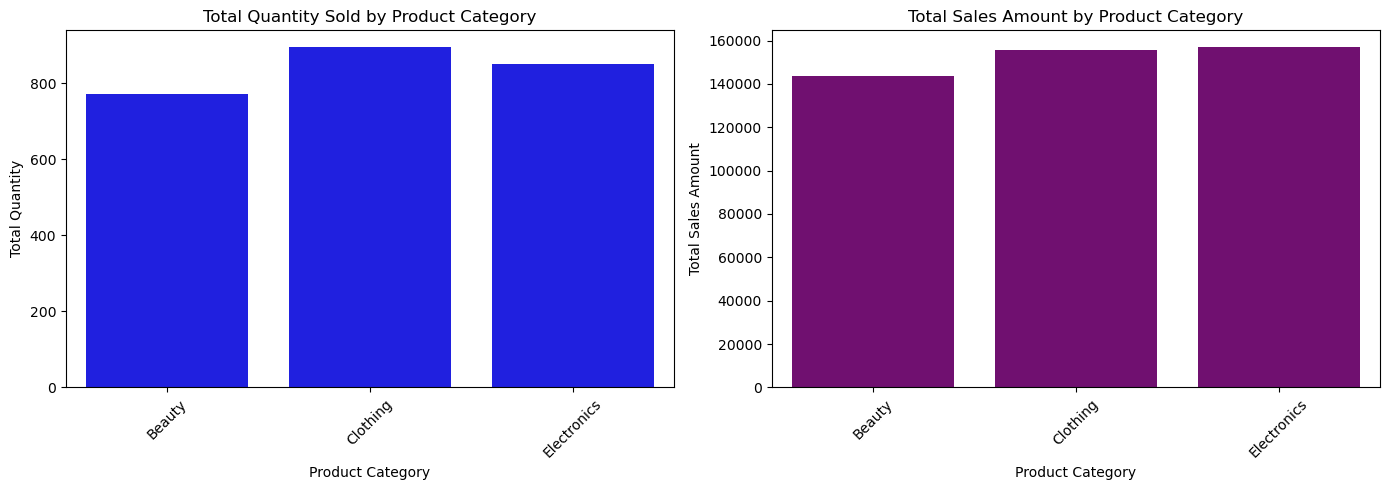

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

Category_Summary = df.groupby('Product Category')[['Quantity', 'Total Amount']].sum()

fig , ax = plt.subplots(1 , 2, figsize=(14,5))

sns.barplot(x=Category_Summary.index, y=Category_Summary['Quantity'], ax=ax[0], color='Blue')
ax[0].set_title('Total Quantity Sold by Product Category')
ax[0].set_xlabel('Product Category')
ax[0].set_ylabel('Total Quantity')
ax[0].tick_params(axis='x', rotation=45)

sns.barplot(x=Category_Summary.index, y=Category_Summary['Total Amount'],ax=ax[1],color='purple')
ax[1].set_title ('Total Sales Amount by Product Category')
ax[1].set_xlabel ('Product Category')
ax[1].set_ylabel ('Total Sales Amount')
ax[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


# Create a pie chart for showing The percentage for each product category

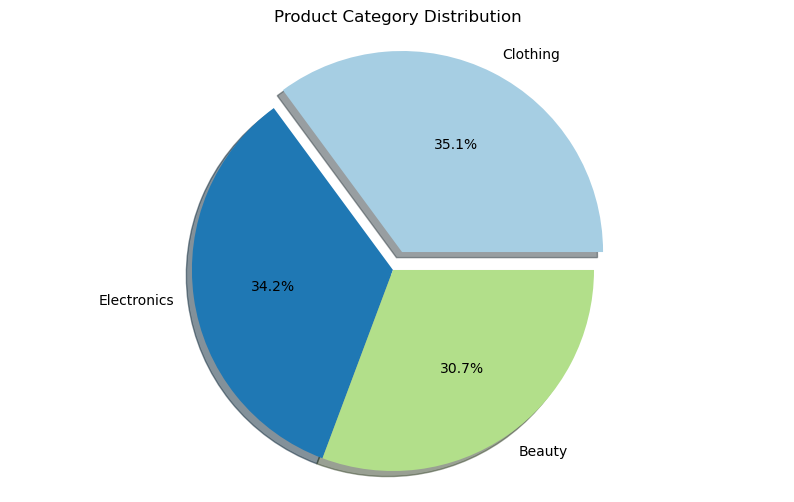

In [18]:
Category_Counts = df['Product Category'].value_counts()

explode_list = [0.1 if i == Category_Counts.idxmax() else 0 for i in Category_Counts.index]

plt.figure(figsize=(10,6))

plt.pie(
    Category_Counts,
    labels=Category_Counts.index,
    autopct='%1.1f%%',
    colors=plt.cm.Paired.colors,
    explode=explode_list,
    shadow=True
)

plt.title('Product Category Distribution')
plt.axis('equal')
plt.show()

# Split the dates into day,month and year

In [19]:
df['Date'] = pd.to_datetime(df['Date'])
df['Month']=df['Date'].dt.month_name()
df['Month']

C:\Users\aditi\AppData\Local\Temp\ipykernel_21860\4222256854.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Date'] = pd.to_datetime(df['Date'])


0      November
1      February
2       January
3           May
4           May
         ...   
995         May
996    November
997     October
998    December
999       April
Name: Month, Length: 1000, dtype: object

# Total Sales Amount each month

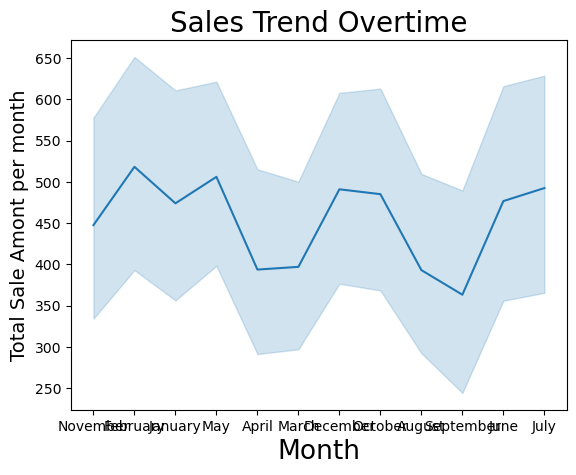

In [20]:
plt.Figure(figsize=(12,2))
sns.lineplot(x='Month', y='Total Amount',data=df)
plt.title('Sales Trend Overtime',fontsize=20)
plt.xlabel('Month', fontsize=19)
plt.ylabel('Total Sale Amont per month', fontsize=14)
plt.show()

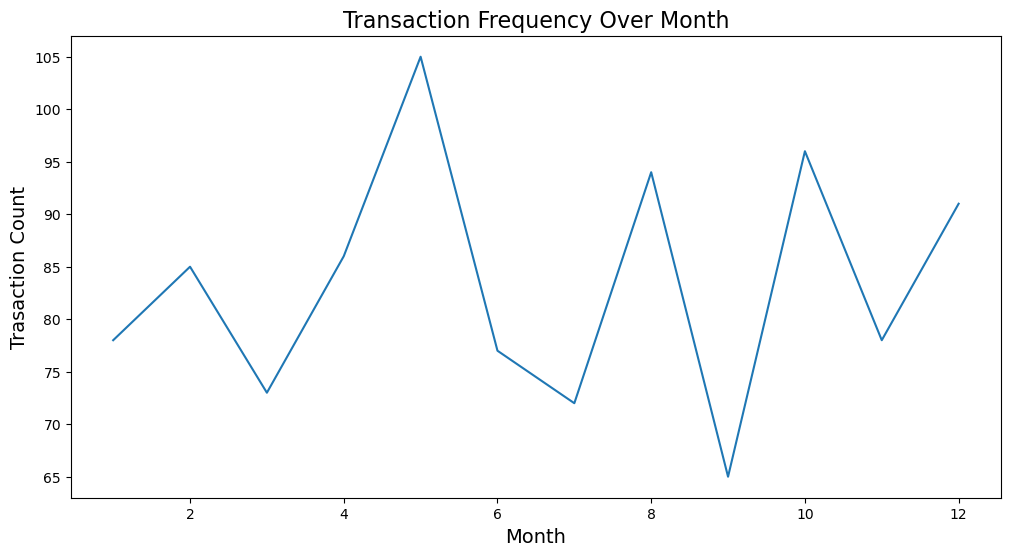

In [21]:
df['Month'] = df['Date'].dt.month
transaction_count = df.groupby('Month')['Transaction ID'].count()

plt.figure(figsize=(12,6))
sns.lineplot(x=transaction_count.index, y=transaction_count.values)
plt.title('Transaction Frequency Over Month', fontsize=16)
plt.xlabel('Month', fontsize=14)
plt.ylabel('Trasaction Count', fontsize=14)
plt.show()


# Transaction Frequency over each month

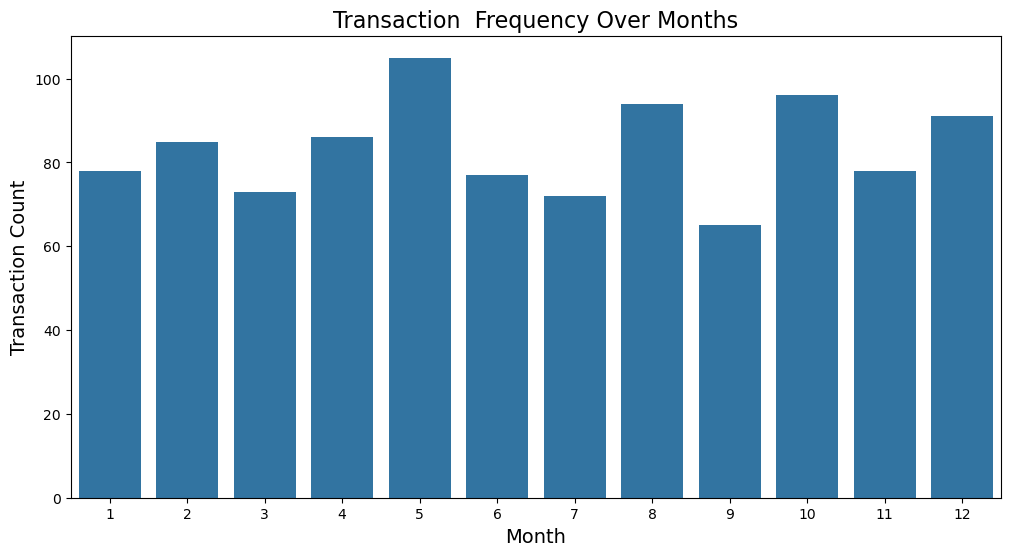

In [22]:
plt.figure(figsize=(12,6))
sns.barplot(x=transaction_count.index, y=transaction_count.values)
plt.title('Transaction  Frequency Over Months', fontsize=16)
plt.xlabel('Month', fontsize=14)
plt.ylabel('Transaction Count',fontsize=14)
plt.show()

# Sales Heatmap

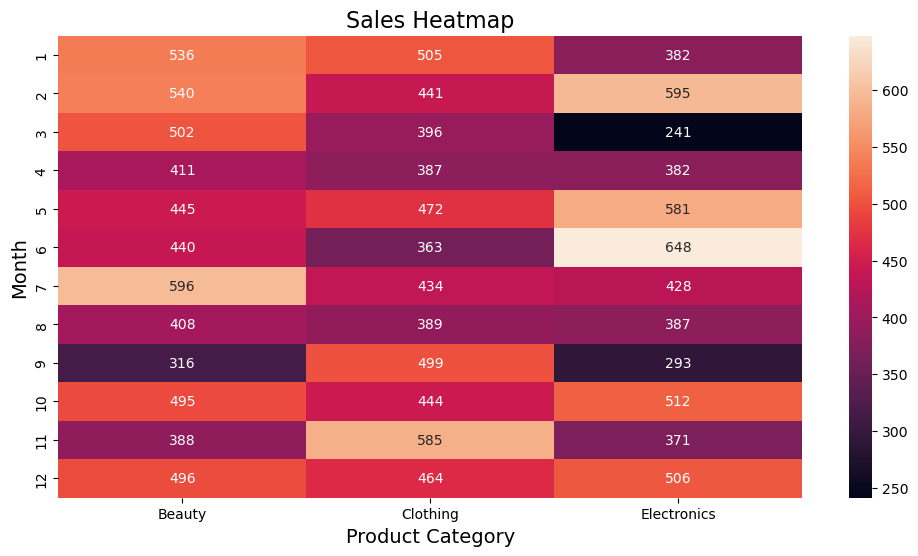

In [23]:
heatmap= df.pivot_table(index='Month', columns='Product Category', values='Total Amount')
plt.figure(figsize=(12,6))
sns.heatmap(heatmap ,annot= True ,fmt='.0f')
plt.title('Sales Heatmap', fontsize=16)
plt.xlabel('Product Category', fontsize=14)
plt.ylabel('Month', fontsize=14)
plt.show()

# Gender  for male and feamale

In [24]:
df['Age'].count()

np.int64(1000)

In [25]:
df[df['Gender'].isin(['Male', 'Female'])]['Gender'].value_counts()

Gender
Female    510
Male      490
Name: count, dtype: int64

Pie chart

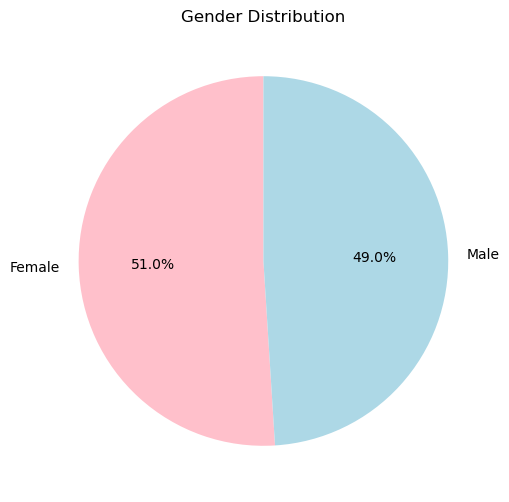

In [26]:
gender_counts = {'Female':510, 'Male':490}

plt.figure(figsize=(6,6))
plt.pie(gender_counts.values(), labels=gender_counts.keys(), autopct='%1.1f%%', colors=['pink' , 'lightblue'], startangle=90)
plt.title('Gender Distribution')
plt.show()

# Bining the Age

In [27]:
age_bins = [0,18,25,35,50,100]
age_group = ['0-18', '19-25', '26-35', '36-50', '50+']
df['Age Group'] = pd.cut (df['Age'],bins = age_bins, labels=age_group)
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Month,Age Group
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,11,26-35
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,2,26-35
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,1,36-50
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,5,36-50
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,5,26-35


# Distribution of the age and gender  column in product category

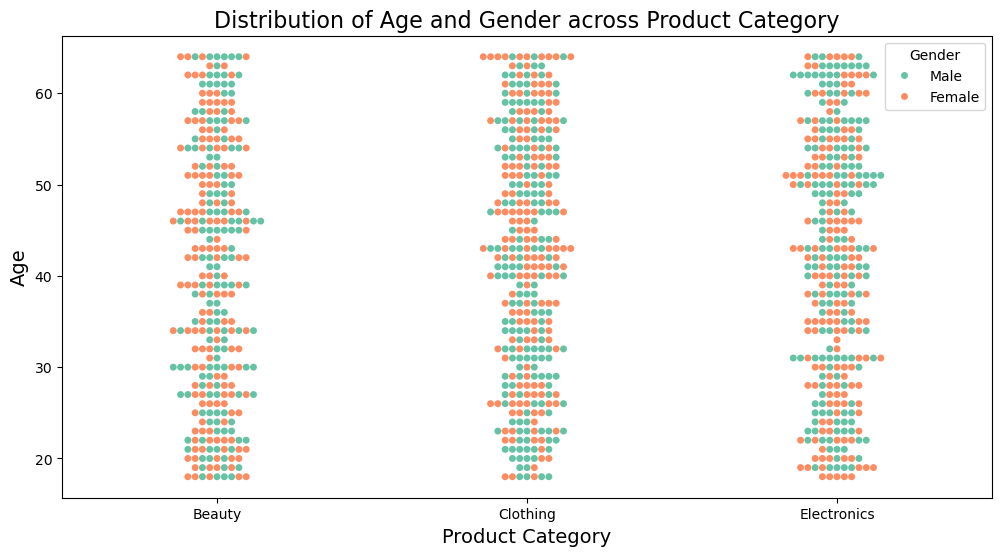

In [29]:
plt.figure(figsize=(12,6))

sns.swarmplot(
    data=df,
    x='Product Category',
    y='Age',
    hue='Gender',
    palette='Set2'
)

plt.title('Distribution of Age and Gender across Product Category', fontsize=16)
plt.xlabel('Product Category', fontsize=14)
plt.ylabel('Age', fontsize=14)
plt.legend(title='Gender', loc='upper right', fontsize=10)

plt.show()

# Histogram for count of age persons

<Axes: title={'center': 'Age of Persons'}, xlabel='Age', ylabel='count'>

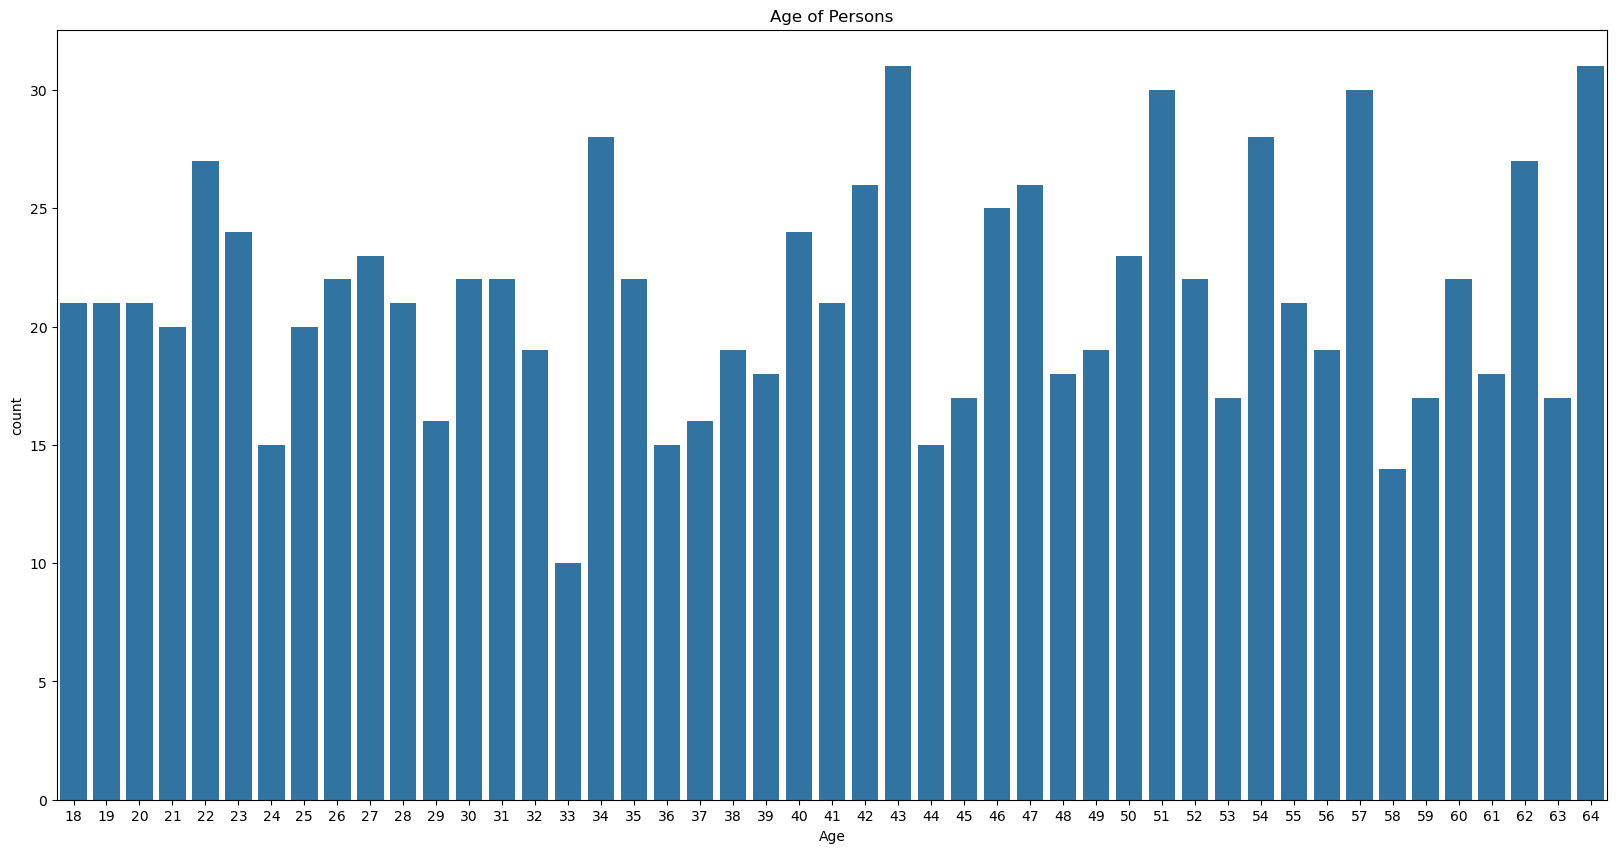

In [31]:
plt.figure(figsize=(20,10))
plt.title('Age of Persons')
plt.xlabel('Age')
sns.countplot(x='Age',data=df)

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    1000 non-null   int64         
 1   Date              1000 non-null   datetime64[ns]
 2   Customer ID       1000 non-null   object        
 3   Gender            1000 non-null   object        
 4   Age               1000 non-null   int64         
 5   Product Category  1000 non-null   object        
 6   Quantity          1000 non-null   int64         
 7   Price per Unit    1000 non-null   int64         
 8   Total Amount      1000 non-null   int64         
 9   Month             1000 non-null   int32         
 10  Age Group         1000 non-null   category      
dtypes: category(1), datetime64[ns](1), int32(1), int64(5), object(3)
memory usage: 75.5+ KB


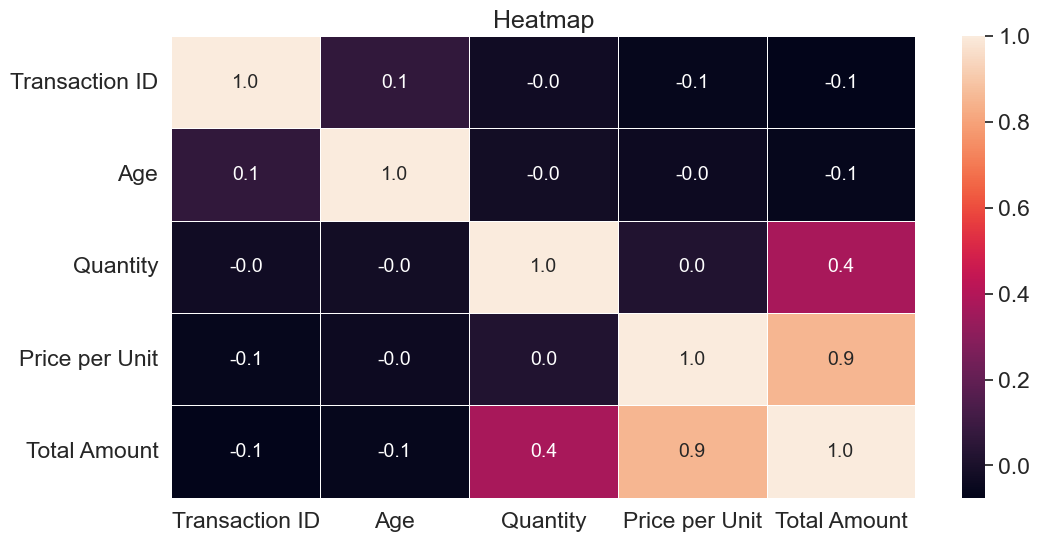

In [36]:

Correlation = df[df.dtypes[df.dtypes == 'int64'].index].corr()

sns.set(font_scale=1.5)

plt.figure(figsize=(12,6))

plt.title('Heatmap', fontsize=18)

ax = sns.heatmap(
    Correlation,
    annot=True,
    annot_kws={'size':14},
    fmt='.1f',
    linewidths=.5
)

plt.show()